# Analisis Distribusi Jarak Penerbangan (Flight Distance) pada Airline Satisfaction Data

**Mata Kuliah:** Pemodelan dan Simulasi  
**Sumber Data:** Kaggle – Airline Satisfaction Data (`data.csv`)  
**Metode:** Fitting Distribusi Eksponensial & Uji Keselarasan Chi-Square (Goodness-of-Fit)

Notebook ini menganalisis pola sebaran jarak penerbangan (*Flight Distance*) penumpang maskapai untuk menguji kesesuaiannya dengan model teoretis **Distribusi Eksponensial**.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

### 1. Pengambilan Data

Data yang digunakan berasal dari Kaggle (*Airline Satisfaction Data*). Dataset ini berisi catatan karakteristik perjalanan dan kepuasan penumpang maskapai penerbangan. Pada analisis pemodelan ini, variabel yang difokuskan adalah **`Flight Distance`** (Jarak Penerbangan), yaitu jarak rute penerbangan yang ditempuh penumpang.

In [50]:
# Import data
df = pd.read_csv('data.csv')

# Bersihkan spasi tak terlihat pada nama kolom
df.columns = df.columns.str.strip()

# Tampilkan 5 data teratas
df[['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance']].head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460
1,Male,disloyal Customer,25,Business travel,Business,235
2,Female,Loyal Customer,26,Business travel,Business,1142
3,Female,Loyal Customer,25,Business travel,Business,562
4,Male,Loyal Customer,61,Business travel,Business,214


### 2. Pemilihan dan Pembersihan Data

Pada tahap ini, dilakukan ekstraksi variabel **`Flight Distance`** serta pembersihan data dari nilai kosong (*missing values*) atau nilai non-positif agar data siap dianalisis secara statistik.

In [51]:
# Ekstraksi dan pembersihan data Flight Distance
flight_dist = df['Flight Distance'].dropna()
flight_dist = flight_dist[flight_dist > 0]

# Hitung statistik deskriptif
N = len(flight_dist)
mean_dist = flight_dist.mean()
median_dist = flight_dist.median()
min_dist = flight_dist.min()
max_dist = flight_dist.max()
std_dist = flight_dist.std()

print(f"Jumlah Observasi (N): {N}")
print(f"Rata-rata (Mean): {mean_dist:.2f}")
print(f"Median: {median_dist:.2f}")
print(f"Rentang (Min - Max): {min_dist} - {max_dist}")
print(f"Standar Deviasi: {std_dist:.2f}")

Jumlah Observasi (N): 129880
Rata-rata (Mean): 1190.32
Median: 844.00
Rentang (Min - Max): 31 - 4983
Standar Deviasi: 997.45


### 3. Evaluasi Kevalidan Distribusi (Uji Chi-Square Goodness-of-Fit)

Data jarak penerbangan memiliki sifat meluruh ke kanan (*right-skewed*), di mana penerbangan jarak pendek-menengah jauh lebih dominan dibanding penerbangan jarak sangat jauh. Oleh karena itu, dilakukan *fitting* menggunakan **Distribusi Eksponensial** dan diuji kevalidannya dengan statistik *Chi-Square Goodness-of-Fit*.

In [52]:
# 3. Fitting Distribusi Eksponensial & Uji Chi-Square Goodness-of-Fit
loc, scale = stats.expon.fit(flight_dist)

# Mengelompokkan data ke dalam 10 interval kelas (bins)
num_bins = 10
observed_counts, bin_edges = np.histogram(flight_dist, bins=num_bins)

# Menghitung probabilitas ekspektasi berdasarkan CDF Eksponensial
cdf_values = stats.expon.cdf(bin_edges, loc=loc, scale=scale)
expected_probs = np.diff(cdf_values)
expected_counts = expected_probs * N

# Normalisasi total frekuensi ekspektasi
expected_counts = expected_counts * (observed_counts.sum() / expected_counts.sum())

# Uji Chi-Square
chi2_stat, p_val = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Parameter Skala (Mean Fit): {scale:.2f}")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

Parameter Skala (Mean Fit): 1159.32
Chi-Square Statistic: 9070.1970
P-Value: 0.0000


### 4. Visualisasi Plot Histogram dan Kurva Fitting

Pembuatan plot histogram dilakukan untuk melihat sebaran frekuensi/densitas jarak penerbangan riil dan membandingkannya secara langsung dengan kurva teoretis dari **Distribusi Eksponensial**.

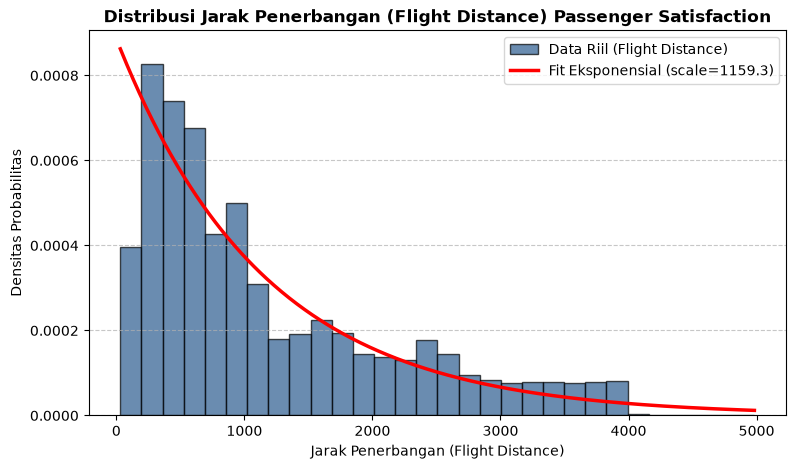

In [ ]:
# 4. Visualisasi Histogram & Kurva Eksponensial
plt.figure(figsize=(9, 5))

# Histogram data riil
counts, bins, patches = plt.hist(flight_dist, bins=30, density=True, color='#2b5c8f', edgecolor='black', alpha=0.7, label='Data Riil (Flight Distance)')

x_axis = np.linspace(min_dist, max_dist, 500)
y_pdf = stats.expon.pdf(x_axis, loc=loc, scale=scale)

plt.plot(x_axis, y_pdf, 'r-', linewidth=2.5, label=f'Fit Eksponensial (scale={scale:.1f})')

plt.title('Distribusi Jarak Penerbangan (Flight Distance) Passenger Satisfaction', fontsize=12, fontweight='bold')
plt.xlabel('Jarak Penerbangan (Flight Distance)', fontsize=10)
plt.ylabel('Densitas Probabilitas', fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('histogram_flight_distance.png', dpi=300, bbox_inches='tight')
plt.show()